# Bistability in Gene Regulation: The Toggle Switch

Module B introduced bistability through a metabolic example — forward inhibition in the PFK1 reaction.
The same dynamical principle governs cell fate decisions at the level of gene expression.

This notebook models the **genetic toggle switch**: two genes whose protein products mutually repress
each other's transcription. Depending on initial conditions (or random fluctuations), the cell locks
into one of two stable expression states — a minimal circuit for cellular memory.

The toggle switch was constructed synthetically in *E. coli* by Gardner, Cantor & Collins (2000,
*Nature* 403, 339–342) to prove that bistability is a property of circuit topology, not special
biochemistry. The same architecture underlies lineage commitment decisions in development and
the kind of virulence-state switching seen in pathogens like *Vibrio cholerae*.


## The Model

Two proteins $u$ and $v$ (e.g. two transcription factors) each repress the other's promoter with
Hill-type cooperativity:

$$\frac{du}{dt} = \frac{\alpha}{1 + v^{n}} - u$$

$$\frac{dv}{dt} = \frac{\alpha}{1 + u^{n}} - v$$

| Parameter | Meaning |
|-----------|---------|
| $\alpha$ | maximal expression rate (when the repressor is absent) |
| $n$ | Hill coefficient — cooperativity of repression |
| $-u$, $-v$ | first-order protein degradation / dilution (rate = 1, sets the time scale) |

At **steady state** $du/dt = dv/dt = 0$. With symmetric parameters the system has either one or
three steady states depending on $\alpha$ and $n$. For $n > 1$ and $\alpha$ large enough: **two stable
states** separated by an **unstable saddle point**.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline

## Phase Portrait: Two Attractors

The **nullclines** are the curves where $du/dt = 0$ and $dv/dt = 0$ respectively.
Their intersections are the steady states. Three intersections → bistability.


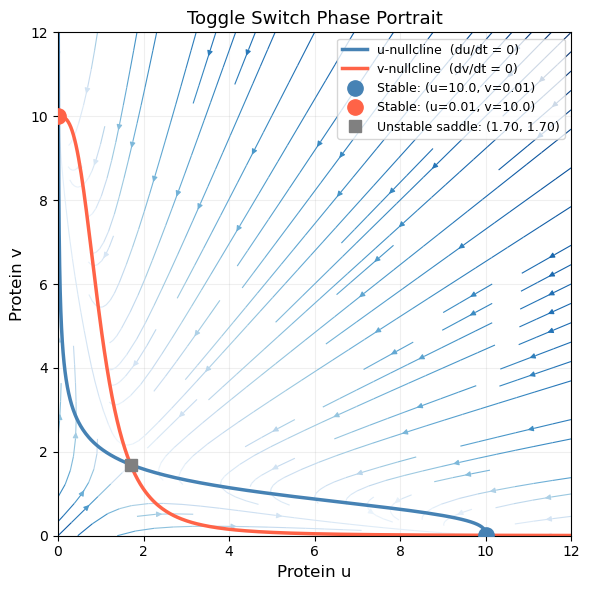

In [3]:
alpha = 10.0
n     = 3

# Nullclines
v_range = np.linspace(0, 12, 400)
u_range = np.linspace(0, 12, 400)

u_nc = alpha / (1 + v_range**n)   # u-nullcline: u = alpha/(1+v^n)
v_nc = alpha / (1 + u_range**n)   # v-nullcline: v = alpha/(1+u^n)

# Fixed points
def rhs(y): return [alpha/(1+y[1]**n) - y[0], alpha/(1+y[0]**n) - y[1]]
fp_hi = fsolve(rhs, [9.5, 0.1])   # high-u attractor
fp_lo = fsolve(rhs, [0.1, 9.5])   # high-v attractor
fp_sd = fsolve(rhs, [2.0, 2.0])   # unstable saddle

# Flow field
ug, vg = np.meshgrid(np.linspace(0, 12, 18), np.linspace(0, 12, 18))
dU = alpha/(1+vg**n) - ug
dV = alpha/(1+ug**n) - vg
speed = np.sqrt(dU**2 + dV**2) + 1e-6

fig, ax = plt.subplots(figsize=(6, 6))

ax.streamplot(ug[0], vg[:,0], dU, dV, color=speed, cmap='Blues',
              density=0.9, linewidth=0.8, arrowsize=0.8)

ax.plot(u_nc, v_range,  color='steelblue',  linewidth=2.5, label='u-nullcline  (du/dt = 0)')
ax.plot(u_range, v_nc, color='tomato',     linewidth=2.5, label='v-nullcline  (dv/dt = 0)')

ax.plot(*fp_hi, 'o', color='steelblue', markersize=11, zorder=5,
        label=f'Stable: (u={fp_hi[0]:.1f}, v={fp_hi[1]:.2f})')
ax.plot(*fp_lo, 'o', color='tomato',    markersize=11, zorder=5,
        label=f'Stable: (u={fp_lo[0]:.2f}, v={fp_lo[1]:.1f})')
ax.plot(*fp_sd, 's', color='gray',      markersize=9,  zorder=5,
        label=f'Unstable saddle: ({fp_sd[0]:.2f}, {fp_sd[1]:.2f})')

ax.set_xlabel('Protein u', fontsize=12)
ax.set_ylabel('Protein v', fontsize=12)
ax.set_title('Toggle Switch Phase Portrait', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 12); ax.set_ylim(0, 12)
ax.grid(alpha=0.2)
plt.tight_layout();

The two blue circles are the stable steady states — one where $u$ is high and $v$ low
(gene u "wins"), the other vice versa. The grey square is the unstable saddle: the system
only lands there if started exactly on the separatrix (the boundary between the two basins).

## Deterministic Simulation: Initial Conditions Determine Fate

Starting from different initial concentrations, the system always converges to one of the two
attractors. Which one depends entirely on the starting point relative to the separatrix.


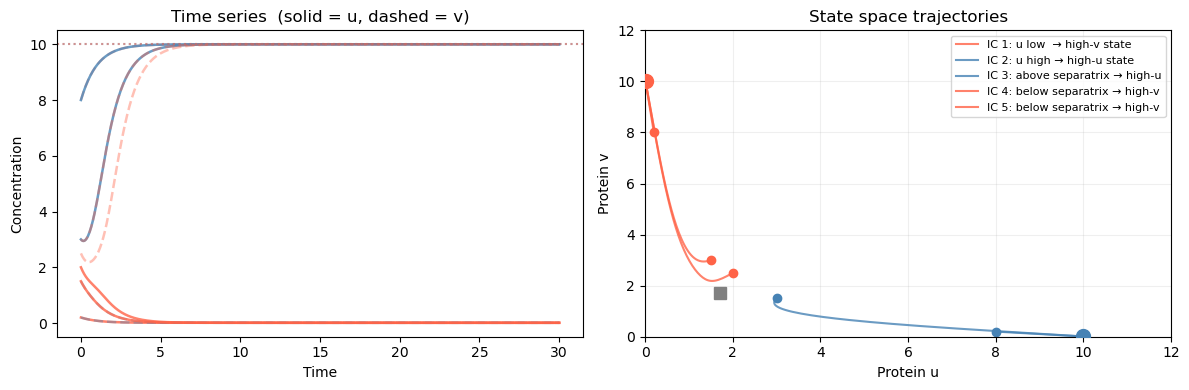

In [4]:
def toggle(t, y, alpha, n):
    u, v = y
    return [alpha/(1+v**n) - u,
            alpha/(1+u**n) - v]

initial_conditions = [
    ([0.2, 8.0], 'tomato',    'IC 1: u low  → high-v state'),
    ([8.0, 0.2], 'steelblue', 'IC 2: u high → high-u state'),
    ([3.0, 1.5], 'steelblue', 'IC 3: above separatrix → high-u'),
    ([1.5, 3.0], 'tomato',    'IC 4: below separatrix → high-v'),
    ([2.0, 2.5], 'tomato',    'IC 5: below separatrix → high-v'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ic, color, label in initial_conditions:
    sol = solve_ivp(toggle, (0, 30), ic, args=(alpha, n), max_step=0.05)
    axes[0].plot(sol.t, sol.y[0], color=color, linewidth=1.8, alpha=0.8)
    axes[0].plot(sol.t, sol.y[1], color=color, linewidth=1.8, alpha=0.4,
                 linestyle='dashed')
    axes[1].plot(sol.y[0], sol.y[1], color=color, linewidth=1.5,
                 alpha=0.8, label=label)
    axes[1].plot(ic[0], ic[1], 'o', color=color, markersize=6)

axes[0].set_xlabel('Time'); axes[0].set_ylabel('Concentration')
axes[0].set_title('Time series  (solid = u, dashed = v)')
axes[0].axhline(fp_hi[0], color='steelblue', linestyle=':', alpha=0.5)
axes[0].axhline(fp_lo[1], color='tomato',    linestyle=':', alpha=0.5)

axes[1].plot(*fp_hi, 'o', color='steelblue', markersize=10, zorder=5)
axes[1].plot(*fp_lo, 'o', color='tomato',    markersize=10, zorder=5)
axes[1].plot(*fp_sd, 's', color='gray',      markersize=8,  zorder=5)
axes[1].set_xlabel('Protein u'); axes[1].set_ylabel('Protein v')
axes[1].set_title('State space trajectories')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_xlim(0, 12); axes[1].set_ylim(0, 12)
axes[1].grid(alpha=0.2)
plt.tight_layout();

## Interactive: When Does Bistability Appear?

The cooperativity $n$ is the critical parameter. For $n = 1$ (no cooperativity) the nullclines
intersect only once: a single steady state. Increasing $n$ creates the S-shaped nullcline that
can cross the other line three times. Try it:


In [5]:
def plot_toggle_phase(alpha=10.0, n=2):
    plt.close('all')
    v_r = np.linspace(0, 14, 400)
    u_r = np.linspace(0, 14, 400)
    u_nc = alpha / (1 + v_r**n)
    v_nc = alpha / (1 + u_r**n)

    def rhs_inner(y): return [alpha/(1+y[1]**n)-y[0], alpha/(1+y[0]**n)-y[1]]
    fps = []
    for guess in [[alpha*0.95,0.1],[0.1,alpha*0.95],[alpha**0.5,alpha**0.5]]:
        fp = fsolve(rhs_inner, guess, full_output=True)
        if fp[2] == 1:
            fps.append(fp[0])

    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot(u_nc, v_r, color='steelblue', linewidth=2.5, label='u-nullcline')
    ax.plot(u_r, v_nc, color='tomato',   linewidth=2.5, label='v-nullcline')
    colors_ = ['steelblue','tomato','gray']
    for i, fp in enumerate(fps):
        ax.plot(*fp, 'o' if i < 2 else 's',
                color=colors_[min(i,2)], markersize=10, zorder=5)
    ax.set_xlabel('u'); ax.set_ylabel('v')
    ax.set_title(f'α = {alpha:.1f},  n = {n}   →   {len(fps)} steady state(s)')
    ax.legend(); ax.set_xlim(0,14); ax.set_ylim(0,14); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

interact(plot_toggle_phase,
         alpha=FloatSlider(min=1, max=20, step=0.5, value=10, description='α'),
         n=IntSlider(min=1, max=5, step=1, value=2, description='n'));

interactive(children=(FloatSlider(value=10.0, description='α', max=20.0, min=1.0, step=0.5), IntSlider(value=2…

## Stochastic Switching: Noise-Induced Cell Fate Transitions

In a real cell, gene expression is noisy. Every transcription and translation event is a
stochastic chemical reaction. Even in a bistable system, this molecular noise can push the
cell over the separatrix, causing a spontaneous switch from one expression state to the other.

We model this with the **Euler–Maruyama** scheme: standard ODE integration with an additive
random increment at each step:

$$u_{i+1} = u_i + \underbrace{\left(\frac{\alpha}{1+v_i^n} - u_i\right)\Delta t}_{\text{deterministic}} + \underbrace{\sigma \sqrt{\Delta t}\, Z_i}_{\text{noise}},\quad Z_i \sim \mathcal{N}(0,1)$$

The $\sqrt{\Delta t}$ scaling correctly represents the statistics of random fluctuations
in continuous time (Wiener process increments have variance $\propto \Delta t$).

**Biological interpretation**: $\sigma$ captures the amplitude of transcriptional bursting
and translational noise. Increasing $\sigma$ increases the rate of spontaneous state switching.


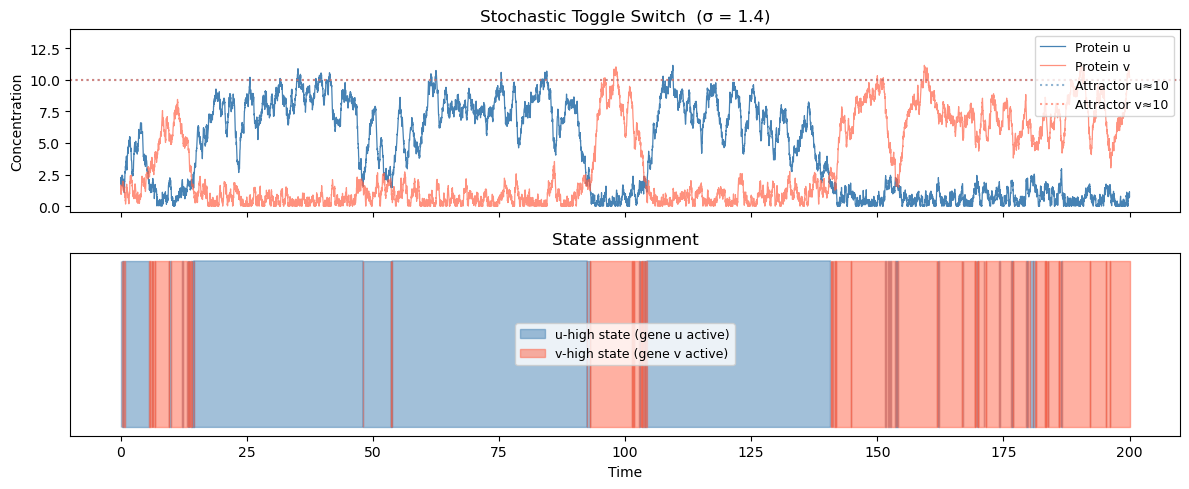

In [11]:
def simulate_toggle_noisy(u0, v0, alpha, n, sigma, T=200, dt=0.02, seed=0):
    """Euler–Maruyama integration of the toggle switch with additive noise."""
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    sqrt_dt = np.sqrt(dt)
    t  = np.arange(n_steps + 1) * dt
    U  = np.empty(n_steps + 1)
    V  = np.empty(n_steps + 1)
    U[0], V[0] = u0, v0
    for i in range(n_steps):
        U[i+1] = max(U[i] + (alpha/(1+V[i]**n) - U[i]) * dt
                     + sigma * sqrt_dt * rng.standard_normal(), 0.0)
        V[i+1] = max(V[i] + (alpha/(1+U[i]**n) - V[i]) * dt
                     + sigma * sqrt_dt * rng.standard_normal(), 0.0)
    return t, U, V

# Demonstrate switching starting near the saddle
sigma = 1.4

t, U, V = simulate_toggle_noisy(
    fp_sd[0] + 0.05, fp_sd[1] - 0.05,   # near the saddle
    alpha, n, sigma, T=200, seed=3
)

saddle_threshold = fp_sd[0]   # ≈ 1.7

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, U, color='steelblue', linewidth=0.9, label='Protein u')
axes[0].plot(t, V, color='tomato',   linewidth=0.9, label='Protein v', alpha=0.7)
axes[0].axhline(fp_hi[0], color='steelblue', linestyle=':', alpha=0.6,
                label=f'Attractor u≈{fp_hi[0]:.0f}')
axes[0].axhline(fp_lo[1], color='tomato',   linestyle=':', alpha=0.6,
                label=f'Attractor v≈{fp_lo[1]:.0f}')
axes[0].set_ylabel('Concentration')
axes[0].set_title(f'Stochastic Toggle Switch  (σ = {sigma})')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_ylim(-0.5, 14)

# Shade dominant state
dominant_u = U > saddle_threshold
axes[1].fill_between(t,  0, 1, where= dominant_u, color='steelblue', alpha=0.5,
                     label='u-high state (gene u active)')
axes[1].fill_between(t,  0, 1, where=~dominant_u, color='tomato',   alpha=0.5,
                     label='v-high state (gene v active)')
axes[1].set_yticks([]); axes[1].set_xlabel('Time')
axes[1].set_title('State assignment')
axes[1].legend(fontsize=9)

plt.tight_layout();

Each horizontal band of colour represents time spent in one gene-expression state.
The system switches spontaneously — no external signal, just molecular noise driving the
concentration past the separatrix.

## Stationary Distribution: The Noise-Level Controls How Often Cells Switch

Run for a long time and collect the distribution of $u$ values. The result is a **bimodal
histogram** — the two peaks correspond to the two stable states. The relative peak heights
reflect how much time the system spends in each state.

Try different noise levels with the slider: below the switching threshold, only one peak appears.


In [12]:
def plot_stochastic_toggle(sigma=1.1, seed=42):
    plt.close('all')
    t_long, U_long, V_long = simulate_toggle_noisy(
        fp_sd[0]+0.05, fp_sd[1]-0.05,
        alpha, n, sigma, T=1500, dt=0.02, seed=seed
    )
    n_sw = int(np.sum(np.abs(np.diff((U_long > saddle_threshold).astype(int)))))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(t_long, U_long, color='steelblue', linewidth=0.6, alpha=0.85)
    axes[0].axhline(fp_hi[0], color='steelblue', linestyle=':', alpha=0.5)
    axes[0].axhline(fp_lo[1], color='tomato',   linestyle=':', alpha=0.5)
    axes[0].set_xlabel('Time'); axes[0].set_ylabel('Protein u')
    axes[0].set_title(f'σ = {sigma:.2f}  |  {n_sw} state switches')
    axes[0].set_ylim(-0.5, 13)

    axes[1].hist(U_long, bins=60, color='steelblue', alpha=0.75, edgecolor='white',
                 linewidth=0.3)
    axes[1].axvline(fp_hi[0], color='steelblue', linestyle='--', linewidth=1.5,
                    label=f'Attractor u≈{fp_hi[0]:.0f}')
    axes[1].axvline(fp_lo[0], color='tomato',   linestyle='--', linewidth=1.5,
                    label=f'Attractor u≈{fp_lo[0]:.2f}')
    axes[1].set_xlabel('Protein u'); axes[1].set_ylabel('Count')
    axes[1].set_title('Stationary distribution (bimodal)')
    axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()

from ipywidgets import interact, FloatSlider, IntSlider
interact(plot_stochastic_toggle,
         sigma=FloatSlider(min=0.3, max=2.0, step=0.1, value=1.1,
                           description='noise σ', continuous_update=False),
         seed=IntSlider(min=0, max=20, step=1, value=42,
                        description='seed', continuous_update=False));

interactive(children=(FloatSlider(value=1.1, continuous_update=False, description='noise σ', max=2.0, min=0.3)…

## Summary

The toggle switch demonstrates that bistability is not a metabolic curiosity — it is a
**universal property of nonlinear circuits with mutual repression**:

- Two mutually repressing genes produce two stable expression states.
- Which state a cell occupies depends on its history (or initial conditions).
- Molecular noise drives spontaneous transitions; their rate depends on noise amplitude and
  barrier height (controlled by $\alpha$ and $n$).
- A long noisy time series shows a **bimodal distribution** — the computational signature of
  bistability that is directly measurable in single-cell experiments.

**Connection to Nielsen et al.**: the bimodal population distributions seen in *V. cholerae*
virulence switching are the experimental counterpart of this histogram.

**Next — Module C**: What if instead of two mutually repressing components, we connect
**three** repressors in a ring? Mutual repression becomes cyclic repression.
The system can no longer settle into either state — it oscillates.
That circuit is the repressilator.
